In [1]:
%pip install gymnasium numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# -------------------------------------------------
# Create Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of States:", n_states)
print("Number of Actions:", n_actions)

Number of States: 16
Number of Actions: 4


In [4]:

# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 3000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100



In [5]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))
episode_rewards = []


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

# Write your code here
def epsilon_greedy_action(state, epsilon):

    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()

    else:
        # Exploitation
        return np.argmax(Q[state])


In [6]:
# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode



In [7]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

# Write your code here
epsilon = epsilon_start

for episode_num in range(num_episodes):

    # Generate complete episode
    episode = generate_episode(epsilon)

    # Store episode reward
    total_reward = sum(
        reward for _, _, reward in episode
    )

    episode_rewards.append(total_reward)

    # Calculate return
    G = 0

    # Traverse episode backwards
    for state, action, reward in reversed(episode):

        G = gamma * G + reward

        # Incremental MC update
        Q[state, action] += alpha * (
            G - Q[state, action]
        )

    # Reduce exploration gradually
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    # Show progress
    if (episode_num + 1) % 2000 == 0:

        print(
            f"Episode {episode_num + 1}/{num_episodes} | "
            f"Epsilon: {epsilon:.4f} | "
            f"Average Reward: "
            f"{np.mean(episode_rewards[-1000:]):.3f}"
        )


Episode 2000/3000 | Epsilon: 0.3678 | Average Reward: 0.398


In [8]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)


In [9]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name: Prakash C ")
    print("Register Number: 212223240122")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)




Final Q-table:
[[0.389 0.65  0.326 0.507]
 [0.486 0.    0.471 0.229]
 [0.377 0.51  0.409 0.369]
 [0.446 0.    0.285 0.182]
 [0.518 0.715 0.    0.503]
 [0.    0.    0.    0.   ]
 [0.    0.776 0.    0.492]
 [0.    0.    0.    0.   ]
 [0.704 0.    0.806 0.719]
 [0.85  0.795 0.866 0.   ]
 [0.643 0.986 0.    0.774]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.342 0.941 0.501]
 [0.88  0.982 1.    0.819]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.65  0.486 0.51  0.446]
 [0.715 0.    0.776 0.   ]
 [0.806 0.866 0.986 0.   ]
 [0.    0.941 1.    0.   ]]
Name: Prakash C 
Register Number: 212223240122

Learned Policy:
[['D' 'L' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.667


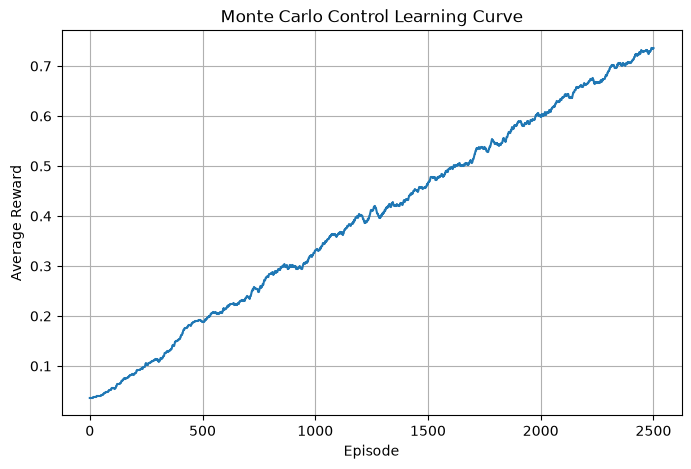

In [10]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()